# Titanic Model Improvement with Cross-Validation and Hyperparameter Tuning

## Project Overview

This is my sixth Python data science project.

In this project, I improve my previous Titanic machine learning model by using a more professional machine learning workflow.

The goal is to improve model performance and make the workflow cleaner using:

- Feature engineering
- Cross-validation
- Preprocessing pipeline
- One-hot encoding
- Hyperparameter tuning
- GridSearchCV
- Model comparison
- Kaggle submission file

This project builds on the previous Titanic Survival Prediction project.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [65]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [66]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [67]:
train.shape

train.info()

train.isnull().sum().sort_values(ascending=False)

test.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Cabin          327
Age             86
Fare             1
Name             0
Pclass           0
PassengerId      0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

## Model Improvement Plan

In the previous project, I manually cleaned and encoded the data.

In this project, I will improve the workflow by using:

1. Feature engineering
2. Pipeline
3. ColumnTransformer
4. Cross-validation
5. Hyperparameter tuning

This makes the project cleaner, easier to reproduce, and more professional.

In [68]:
def create_features(df):
    df = df.copy()

    # Family size
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Is passenger alone?
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    #Fare per person
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

    # Extract title from passenger name
    df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\\.", expand=False)

    # Group rare titles
    rare_titles = [
        "Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
        "Rev", "Sir", "Jonkheer", "Dona"
    ]

    df["Title"] = df["Title"].replace(rare_titles, "Rare")
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # Extract deck from Cabin
    df["Deck"] = df["Cabin"].str[0]
    df["Deck"] = df["Deck"].fillna("Unknown")

    return df

In [69]:
train_fe = create_features(train)
test_fe = create_features(test)

train_fe.head()

train_fe[["Name", "Title", "FamilySize", "IsAlone", "FarePerPerson", "Cabin", "Deck"]].head()

,Name,Title,FamilySize,IsAlone,FarePerPerson,Cabin,Deck
0,"Braund, Mr. Owen Harris",Mr,2,0,3.62500,NaN,Unknown
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,35.64165,C85,C
2,"Heikkinen, Miss. Laina",Miss,1,1,7.92500,NaN,Unknown
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,26.55000,C123,C
4,"Allen, Mr. William Henry",Mr,1,1,8.05000,NaN,Unknown


In [70]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "Deck"
]

features = numeric_features + categorical_features

target = "Survived"

X = train_fe[features]
y = train_fe[target]

X.head()


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Sex,Embarked,Title,Deck
0,3,22.0,1,0,7.2500,2,0,3.62500,male,S,Mr,Unknown
1,1,38.0,1,0,71.2833,2,0,35.64165,female,C,Mrs,C
2,3,26.0,0,0,7.9250,1,1,7.92500,female,S,Miss,Unknown
3,1,35.0,1,0,53.1000,2,0,26.55000,female,S,Mrs,C
4,3,35.0,0,0,8.0500,1,1,8.05000,male,S,Mr,Unknown


In [71]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 12)
X_valid shape: (179, 12)
y_train shape: (712,)
y_valid shape: (179,)


In [78]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onebot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [82]:
def evaluate_model(model, model_name):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    return {
        "Model": model_name,
        "Mean Accuracy": scores.mean(),
        "Std Accuracy": scores.std()
    }

In [83]:
models = [
    (LogisticRegression(max_iter=1000), "Logistic Regression"),
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (GradientBoostingClassifier(random_state=42), "Gradient Boosting")
]

results = []

for model, model_name in models:
    result = evaluate_model(model, model_name)
    results.append(result)

model_results = pd.DataFrame(results).sort_values("Mean Accuracy", ascending=False)

model_results

,Model,Mean Accuracy,Std Accuracy
2,Gradient Boosting,0.816123,0.033573
0,Logistic Regression,0.816104,0.030929
1,Random Forest,0.790860,0.040784


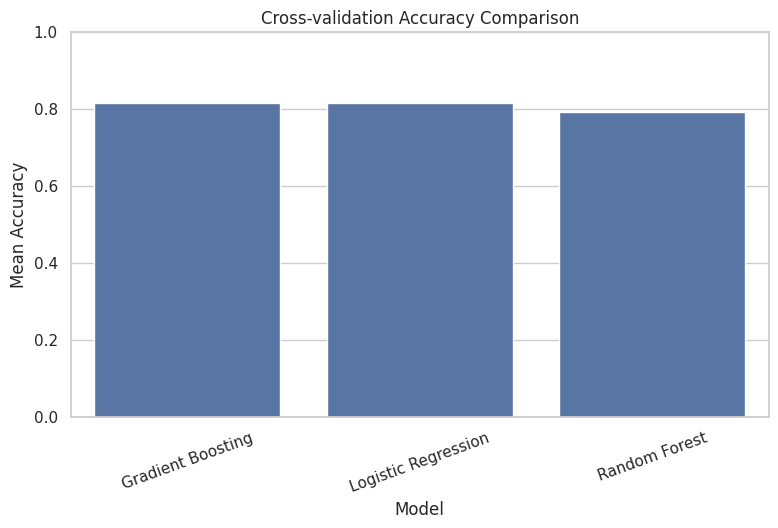

In [84]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Mean Accuracy"
)

plt.title("Cross-validation Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Mean Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.show()

## Insight

Cross-validation gives a more reliable estimate of model performance than a single train-validation split.

In [86]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Pclass',
                                                                                'Age',
                                                                                'SibSp',
                                                                                'Parch',
                                                                                'Fare',
                                                                                'FamilySize',
                                                                                'IsAlone',
                                                                                'FarePerPerson']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent'))...
                                                                               ['Sex',
                                                                                'Embarked',
                                                                                'Title',
                                                                                'Deck'])])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 3, 5, 8, 10],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='accuracy')

In [88]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-validation Accuracy:")
print(rf_search.best_score_)

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 8}

Best Cross-validation Accuracy:
0.8301585738205457


In [90]:
best_rf_model = rf_search.best_estimator_
valid_predictions = best_rf_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, valid_predictions)
print(f"Validation Accuracy: {valid_accuracy:.4f}")

Validation Accuracy: 0.7989


In [91]:
print("Classification Report")
print(classification_report(y_valid, valid_predictions))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



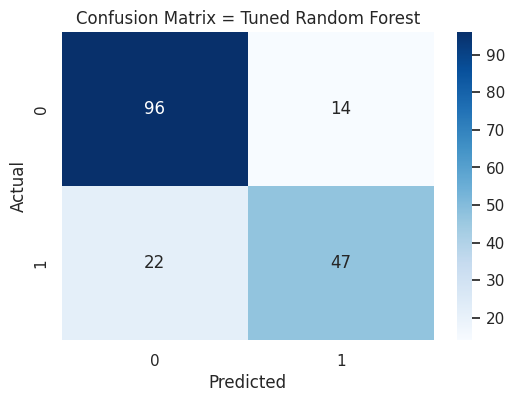

In [94]:
cm = confusion_matrix(y_valid, valid_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix = Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

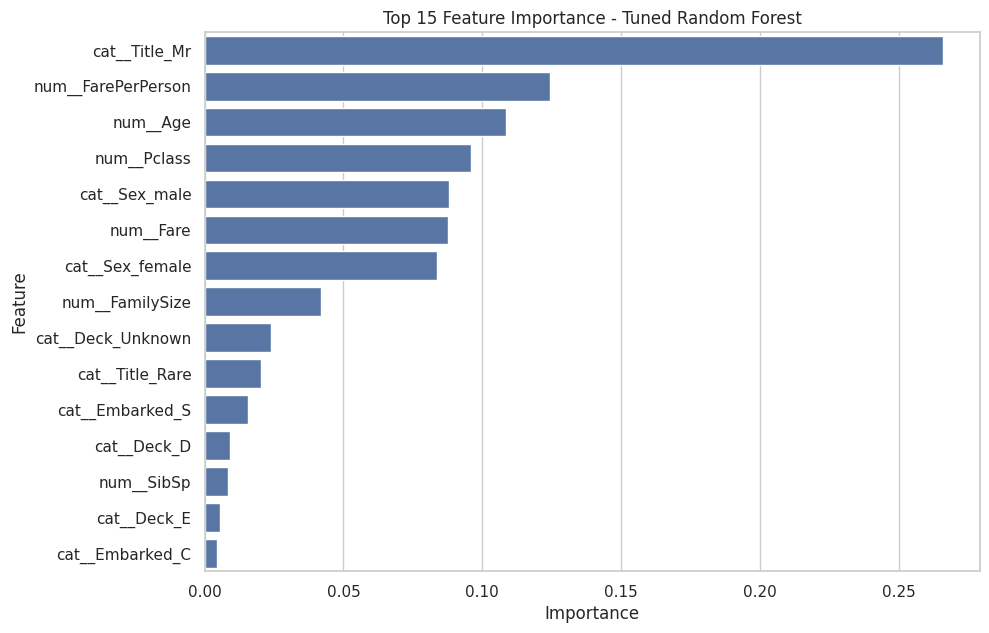

In [97]:
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [98]:
final_model = rf_search.best_estimator_
final_model.fit(X, y)
print("Final model trained on full training data")

Final model trained on full training data


In [99]:
X_test = test_fe[features]
X_test.head()
X_test.isnull().sum()

Pclass            0
Age              86
SibSp             0
Parch             0
Fare              1
FamilySize        0
IsAlone           0
FarePerPerson     1
Sex               0
Embarked          0
Title             0
Deck              0
dtype: int64

In [102]:
test_predictions = final_model.predict(X_test)
test_predictions[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [106]:
submission = pd.DataFrame({
    "PassengerID": test_fe["PassengerId"],
    "Survived": test_predictions
})

submission.head()

submission.to_csv("/kaggle/working/titanic_improved_submission.csv", index=False)
print("Improved submission file created successfully.")

from IPython.display import FileLink

FileLink("/kaggle/working/titanic_improved_submission.csv")

Improved submission file created successfully.


/kaggle/working/titanic_improved_submission.csv

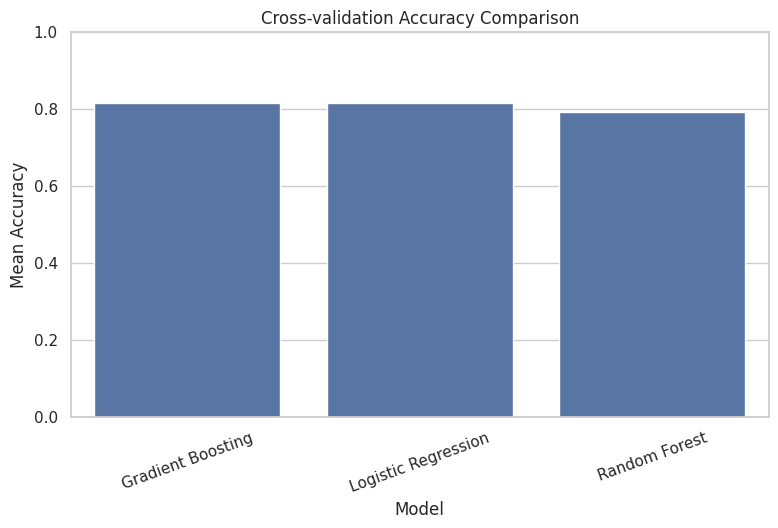

/kaggle/working/titanic_cv_model_comparison.png

In [109]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Mean Accuracy"
)

plt.title("Cross-validation Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Mean Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.savefig("/kaggle/working/titanic_cv_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

FileLink("/kaggle/working/titanic_cv_model_comparison.png")

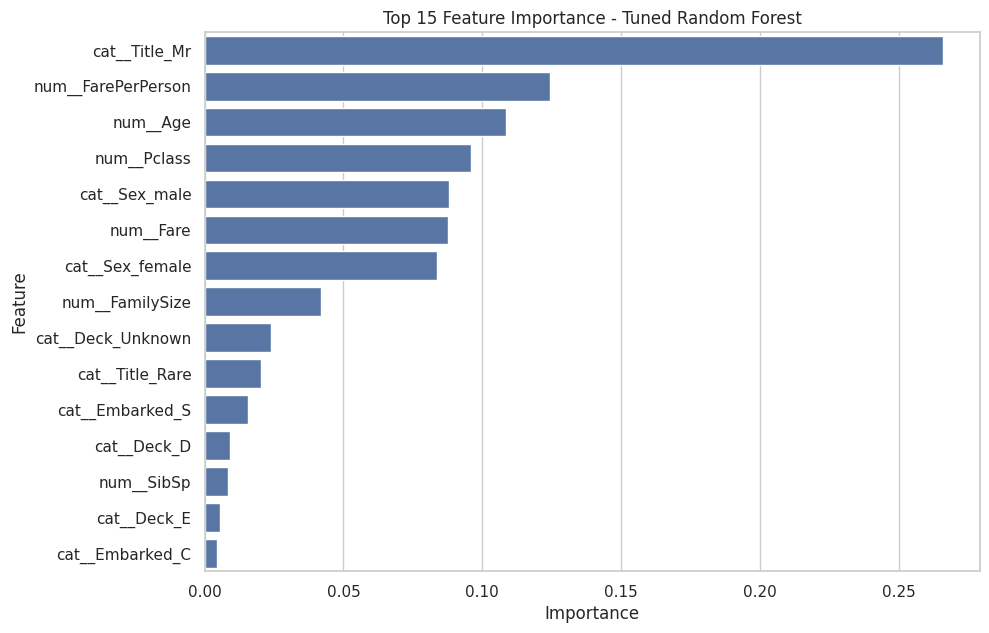

/kaggle/working/titanic_feature_importance.png

In [110]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("/kaggle/working/titanic_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

FileLink("/kaggle/working/titanic_feature_importance.png")

## Key Findings

From this Titanic model improvement project, I found that:

1. Cross-validation gives a more reliable model evaluation than a single train-validation split.
2. Pipeline makes the machine learning workflow cleaner and easier to reproduce.
3. ColumnTransformer helps process numeric and categorical features separately.
4. Feature engineering created useful variables such as FamilySize, IsAlone, FarePerPerson, Title, and Deck.
5. RandomizedSearchCV helped find better hyperparameters for Random Forest.
6. Feature importance showed which features contributed most to model predictions.

## What I Learned

In this project, I practiced:

- Building a machine learning pipeline
- Handling numeric and categorical data separately
- Using SimpleImputer for missing values
- Using OneHotEncoder for categorical variables
- Using StandardScaler for numeric features
- Evaluating models with cross-validation
- Tuning hyperparameters with RandomizedSearchCV
- Analyzing feature importance
- Creating an improved Kaggle submission file

## Next Step

The next step is to learn more advanced model improvement techniques, such as:

- GridSearchCV
- More feature engineering
- Model stacking
- XGBoost
- LightGBM
- Saving and loading trained models